# Angular Momentum Budget

## Introduction

We're going to talk about three key budgets of materially conserved quantities:

1. Angular Momentum
2. Energy
3. Water Vapor

The general idea running through these topics is that we have a quantity that *obeys some conservation principle* embeded in the equations of motion, and that over a "long enough" time period that quantity must be in **steady state** in the atmosphere.

For any quantity in steady state, we must have a balance between local *sources* and *sinks* of that quantity and *flux divergence / convergence* of the same quantity.

### Vertical integrals

In addition to zonal and time averages, we will sometimes employ a vertical integral (weighted by mass):

$$ <A> = \frac{1}{g} \int_0^{p_s} A dp \approx \int_0^{\infty} A \rho dz $$

where $p_s$ is the surface pressure.

## Angular momentum basics

The total angular momentum of the solid Earth and its fluid components is approximately conserved.

Angular momentum is exchanged between the solid Earth and the atmosphere, but on greater than annual timescales, there should be no net exchange.

### Length of day

Changes in the angular momentum of the solid Earth are reflected in fluctuations of the [Length of Day](wiki:Day_length_fluctuations):

:::{figure} https://upload.wikimedia.org/wikipedia/commons/5/5b/Deviation_of_day_length_from_SI_day.svg
:alt: File:Deviation of day length from SI day.svg

Deviation of day length from SI-based day (86'400 s) 1962–2026: daily, moving 365-day average and cumulative. For comparison, displays UTC leap seconds.

Public Domain. [Source from wikimedia](https://commons.wikimedia.org/w/index.php?curid=9395571)
:::


There's clearly lots of interesting low-frequency variability, but for our purposes we'll pay most attention to the annual timescale: fluctuations of order 1 ms. It turns out that these are well-correlated with **seasonal flucutations in atmospheric angular momentum**.

### Comparison of angular momentum to length of day variations

To show this, we'll take a quick look at this figure reproduced from "The Atmospheric General Circulation" by Wallace et al. {cite:p}`Wallace:GenCirc`

:::{figure} ../images/Wallace_Fig3.5.pdf
:alt: Time series of total angular momentum compared against length of day

(Top) Time series of total and relative atmospheric angular momentum AAM indicated by the red and blue curves, respectively, together with length of day LOD indicated by the black curve. The interdecadal variability in LOD attributable to motions in the Earth's mantle has been removed and the curve has been scaled to make it comparible with the AAM curves. The scales at the left and right are different because the total AAM contains the almost constant solid body rotation component. The LOD scale in units of milliseconds is also included at the far right. (Bottom) The corresponding anomlies with respect to the seasonally varying climatological means. Courtesy of Ying Li.

Source: {cite:t}`Wallace:GenCirc`
:::

### Definitions and notation

Let $\vec{r}$ be the position vector from the axis of rotation, and let $\vec{u}_a$ be the absolute velocity as measured in the *inertial* frame.

**Sketch of sphere**

Then we define the **angular momentum**

$$\vec{M} = \vec{r} \times \vec{u}_a $$

and its changes are governed by

$$ \frac{d\vec{M}}{dt} = \vec{r} \times \vec{F} $$

where $\vec{F}$ is the net force, and $\vec{r} \times \vec{F}$ is the net **torque**.

Two important torques we will discuss include the frictional torque and the mountain torque.

Now define the relative velocity $\vec{u}$ through

$$ \vec{u}_a = \vec{\Omega} \times \vec{r} + \vec{u} $$

where $\vec{\Omega}$ is the Earth's rotation vector. So the angular momentum can be written

\begin{align*}
\vec{M} &= \vec{r} \times \left( \vec{\Omega} \times \vec{r} + \vec{u} \right) \\
&= \Omega (a \cos\phi)^2 \hat{\Omega} + \vec{r} \times \vec{u}
\end{align*}

where $\hat{\Omega}$ is a unit vector aligned with the axis of rotation. This is valid for the thin-shell approximation, $z<<a$ where $a$ is the radius of the Earth.

The planetary component dictates the predominant direction of $\vec{M}$, so we are most interested in the component of $\vec{r} \times \vec{u}$ also parallel to $\hat{\Omega}$:

$$ \hat{\Omega} \cdot (\vec{r} \times \vec{u}) = u a \cos\phi $$

So let's define this (scalar) quantity:

$$ M = \Omega a^2 \cos^2\phi + u a \cos\phi $$

where the first term is the **planetary angular momentum** $M_\Omega \equiv \Omega a^2 \cos^2\phi$ and the second term is the **relative angular momentum** $M_r \equiv u a \cos\phi$.

## Absolute versus relative angular momentum in seasonal extremes

The plot below is reproduced from a very nice textbook, "An Introduction to the Global Circulation of the Atmosphere" by [David Randall](https://www.atmos.colostate.edu/people/faculty/randall/) (Colorado State University) {cite:t}`Randall:globalcirc`.

It shows the absolute angular momentum $M$ as well as just the relative component $M_{relative} = ua\cos\phi$ for the seasonal extremes of January and July.

Notice that the relative component is about two orders of magnitude smaller than the absolute.

:::{figure} ../images/angular-momentum-randall.png
:alt: Absolute and relative angular momentum
:width: 800px

The observed absolute (left panels) and relative (right panels) atmopspheric angular momentum per unit mass, for January and July. The units are $10^{7}$ m$^{2}$ s$^{-1}$. Source: {cite:t}`Randall:globalcirc`
:::

Key features of the seasonal variations seem to be that the relative angular momentum $M_r$ is greater in the winter hemisphere, but also that the total $M_r$ integrated over the whole volume of the atmosphere seems to be larger in the N.H. winter (January).

## Plotting angular momentum from ERA5 data

Let's duplicate the plot above using one year of zonal wind ($u$) data from the ERA5.

Even though we're just using a single year, it's still a relatively big calculation because we start with a four dimensional dataset (lat, lon, time, and pressure levels) at hourly resolution. We'll use some "lazy execution" tricks along the way to get our calculation done.

### Lazily load the ERA5 data 

See [these notes](../info/era5.ipynb) for more explanation of what we're doing here.

In [1]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
from arraylake import Client as alClient
from dask.distributed import Client as dClient

In [2]:
alclient = alClient()
alclient.login()

Successfully refreshed tokens! Token stored at /network/rit/home/br546577/.arraylake/token.json

╭───────────────────────────────────────────────── User Details ──────────────────────────────────────────────────╮
│ Name: None None                                                                                                 │
│ Email: brose@albany.edu                                                                                         │
│ Id: 42b3a5b8-e618-4e14-aba8-632532f16692                                                                        │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

In [3]:
repo = alclient.get_repo("earthmover-public/era5")
session = repo.readonly_session("main")
pressure_spatial = xr.open_zarr(session.store, group="pressure/spatial", chunks={})
pressure_spatial

  2026-09-17T05:02:25.585628Z  WARN aws_smithy_http_client::client::tls::rustls_provider::build_connector: native root CA certificate loading errors: [Error { context: "failed to read PEM from file", kind: Io { inner: Os { code: 13, kind: PermissionDenied, message: "Permission denied" }, path: "/etc/ssl/certs/sendmail.pem" } }, Error { context: "failed to read PEM from file", kind: Io { inner: Os { code: 13, kind: PermissionDenied, message: "Permission denied" }, path: "/etc/pki/tls/certs/sendmail.pem" } }]
    at /home/conda/feedstock_root/build_artifacts/bld/rattler-build_icechunk_1785432413/build_env/.cargo/registry/src/index.crates.io-1949cf8c6b5b557f/aws-smithy-http-client-1.1.12/src/client/tls/rustls_provider.rs:73



<xarray.Dataset> Size: 327TB
Dimensions:         (valid_time: 756048, pressure_level: 13, latitude: 721,
                     longitude: 1440)
Coordinates:
  * valid_time      (valid_time) datetime64[ns] 6MB 1940-01-01 ... 2026-03-31...
  * pressure_level  (pressure_level) float64 104B 1e+03 925.0 ... 100.0 50.0
  * latitude        (latitude) float64 6kB 90.0 89.75 89.5 ... -89.75 -90.0
  * longitude       (longitude) float64 12kB 0.0 0.25 0.5 ... 359.2 359.5 359.8
    lsm             (latitude, longitude) float32 4MB dask.array<chunksize=(721, 1440), meta=np.ndarray>
    sdor            (latitude, longitude) float32 4MB dask.array<chunksize=(721, 1440), meta=np.ndarray>
    slor            (latitude, longitude) float32 4MB dask.array<chunksize=(721, 1440), meta=np.ndarray>
    z_sfc           (latitude, longitude) float32 4MB dask.array<chunksize=(721, 1440), meta=np.ndarray>
Data variables:
    r               (valid_time, pressure_level, latitude, longitude) float32 41TB dask.array<chunksize=(1, 1, 721, 1440), meta=np.ndarray>
    pv              (valid_time, pressure_level, latitude, longitude) float32 41TB dask.array<chunksize=(1, 1, 721, 1440), meta=np.ndarray>
    t               (valid_time, pressure_level, latitude, longitude) float32 41TB dask.array<chunksize=(1, 1, 721, 1440), meta=np.ndarray>
    v               (valid_time, pressure_level, latitude, longitude) float32 41TB dask.array<chunksize=(1, 1, 721, 1440), meta=np.ndarray>
    q               (valid_time, pressure_level, latitude, longitude) float32 41TB dask.array<chunksize=(1, 1, 721, 1440), meta=np.ndarray>
    u               (valid_time, pressure_level, latitude, longitude) float32 41TB dask.array<chunksize=(1, 1, 721, 1440), meta=np.ndarray>
    z               (valid_time, pressure_level, latitude, longitude) float32 41TB dask.array<chunksize=(1, 1, 721, 1440), meta=np.ndarray>
    w               (valid_time, pressure_level, latitude, longitude) float32 41TB dask.array<chunksize=(1, 1, 721, 1440), meta=np.ndarray>
Attributes: (12/46)
    Conventions:                CF-1.7
    title:                      ERA5 Hourly Global Reanalysis - chunked for s...
    summary:                    ERA5 is the fifth generation ECMWF atmospheri...
    keywords:                   ERA5, reanalysis, atmosphere, climate, ECMWF,...
    keywords_vocabulary:        GCMD Science Keywords
    id:                         era5
    ...                         ...
    proj:code:                  EPSG:4326
    proj:epsg:                  4326
    GRIB_centre:                ecmf
    GRIB_centreDescription:     European Centre for Medium-Range Weather Fore...
    GRIB_subCentre:             0
    history:                    2026-05-05T13:36 GRIB to CDM+CF via cfgrib-0....

### Set up a dask cluster for parallelization

Tools for accelerating the data processing depend on where and how we are running the code.

We will likely get the best performance running on https://jupyterlab.its.albany.edu/ and launching a large Dask worker cluster (option 2 below).

But on a typical multicore laptop, we can still get some acceleration by invoking a local worker cluster (option 1 below).

In [4]:
# ## Option 1: run this on a laptop
# ##  Comment out this cell if using option 2
# dclient = dClient()
# dclient

In [5]:
## Option 2: If running this notebook on jupyterlab.its.albany.edu, uncomment and run this cell
##  This sets up a cluster of workers to parallelize the calculations

from dask_jobqueue import SLURMCluster

cluster = SLURMCluster(cores=64, # size of a single job -- typically one node of the HPC cluster
                       memory="374GB",  # the max memory on the 64-core burst-daes nodes, I believe
                       walltime="01:00:00",
                       queue="burst-daes",
                      )

cluster.adapt(minimum=1, maximum=3)
dclient = dClient(cluster)
dclient

Connection method: Cluster object,Cluster type: dask_jobqueue.SLURMCluster
Dashboard: http://169.226.65.130:8787/status,
Dashboard: http://169.226.65.130:8787/status,Workers: 0
Total threads: 0,Total memory: 0 B
Comm: tcp://169.226.65.130:7941,Workers: 0
Dashboard: http://169.226.65.130:8787/status,Total threads: 0
Started: Just now,Total memory: 0 B


### Planetary angular momentum

First we'll do the easy part: computing the planetary angular momentum from

$$ M_\Omega = \Omega a^2 \cos^2\phi $$

We just need the planetary constants $\Omega$ and $a$ as well as the latitude axis from our dataset:

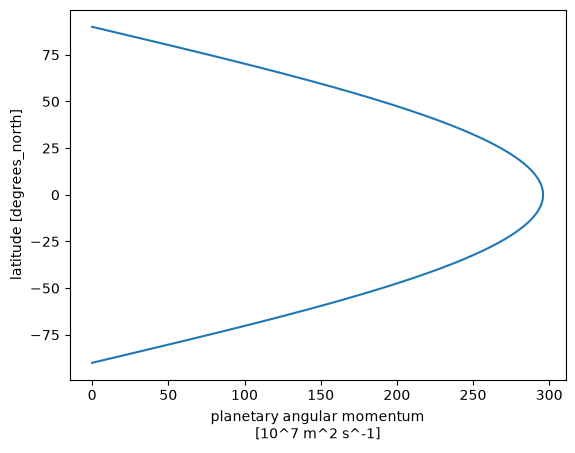

In [6]:
a = 6.371E6  # the mean planetary radius in meters
sidereal_period = (23*60 + 56)*60 + 4.09053  # Earth's rotational period in seconds -- just shy of one day
Omega = 2*np.pi / sidereal_period  # Earth's angular rotation rate (radians / second)

latitude = pressure_spatial.latitude

Mplanetary = Omega * a**2 * np.cos(np.deg2rad(latitude)) / 1E7 # put in same units as Randall figure
Mplanetary.attrs['long_name'] = 'planetary angular momentum'
Mplanetary.attrs['units'] = '10^7 m^2 s^-1'
Mplanetary.plot(y='latitude');

### Computing relative angular momentum from zonal wind data

The formula is

$$ M_r = u a \cos\phi $$

This is a simple function of zonal wind $u$ and latitude $\phi$ (which is itself a property of the zonal wind data). Let's go ahead and code this up as a callable Python function:

In [7]:
def relative_angular_momentum(u):
    '''Compute relative angular momentum in units of 10^7 m^2 s^-1'''
    value = u * a * np.cos(np.deg2rad(u.latitude)) / 1E7
    value.attrs['long_name'] = 'relative angular momentum'
    value.attrs['units'] = '10^7 m^2 s^-1'
    value.coords['geopotential_height'] = geopotential_height(value.pressure_level)
    value.geopotential_height.attrs['units'] = 'km'
    return value

We are mainly concerned here with zonal- and time averages. We will focus on the months of January and July for comparison against Randall's figure.

For no particular reason, we will focus on the year 2021.

#### Side note: transforming to height coordinates

Since Randall's figure is plotted with respect to height rather than pressure, let's add a new coordinate dimension to our dataset that represents approximate geopotential height.

This function just computes the integrated hydrostatic balance relation for an ideal gas at a constant reference temperature (which is all we need here since it's just for visual comparison):

In [8]:
def geopotential_height(p):
    '''Compute approximate geopotential height (km) from pressure based on hydrostatic balance at a reference temperature'''
    Rd = 287  # gas constant for dry air
    g = 9.8  # acceleration due to gravity
    Tref = 280.  # reference temperature in Kelvin
    ps = 1000.  # reference surface pressure in hPa
    return Rd*Tref/g * np.log(ps / p) / 1000.

We *can* write fully lazy code that specifies all our data transformations and reductions before actually doing any computations. Here's an example:

In [9]:
#  We are NOT going to compute and plot results from this code
#  But this is to demonstrate the fully "lazy" way to set it up
u = pressure_spatial.u.sel(valid_time="2021")
Mrelative = relative_angular_momentum(u)
Mrelative_zonal = Mrelative.mean(dim='longitude')
Mrelative_monthly = Mrelative_zonal.groupby(Mrelative_zonal.valid_time.dt.month).mean(dim='valid_time')
Mrelative_monthly

<xarray.DataArray (month: 12, pressure_level: 13, latitude: 721)> Size: 900kB
dask.array<transpose, shape=(12, 13, 721), dtype=float64, chunksize=(1, 1, 721), chunktype=numpy.ndarray>
Coordinates:
  * month                (month) int64 96B 1 2 3 4 5 6 7 8 9 10 11 12
  * pressure_level       (pressure_level) float64 104B 1e+03 925.0 ... 50.0
    geopotential_height  (pressure_level) float64 104B 0.0 0.6393 ... 24.57
  * latitude             (latitude) float64 6kB 90.0 89.75 89.5 ... -89.75 -90.0
Attributes: (12/32)
    GRIB_paramId:                             131
    GRIB_dataType:                            an
    GRIB_numberOfPoints:                      1038240
    GRIB_typeOfLevel:                         isobaricInhPa
    GRIB_stepUnits:                           1
    GRIB_stepType:                            instant
    ...                                       ...
    GRIB_totalNumber:                         0
    GRIB_units:                               m s**-1
    stored_direction:                         decreasing
    axis:                                     Y
    long_name:                                relative angular momentum
    units:                                    10^7 m^2 s^-1

We can see that our reductions leave us with 12 individual latitude-pressure cross-sections.

Note that this is a very "cheap" operation because we haven't actually done the computation yet!

This is an example of "lazy" execution. We've just set up instructions about **how** to calculate the result. The actual computation will only occur when it's need (like when we try to plot a result).

It is possible to go ahead and compute the results for every month.

This commented out code would do it:

In [10]:
# Mrelative_monthly.compute()

However, this will be *very slow* because of the way the data chunks are laid out.

To get decent performance, I will change the order of operations here, and focus just on the months of January and July (since those are plotted in Randall's figure).

I'm also using the `%%time` magic in this cell to measure how long it takes to execute.

In [11]:
%%time
Mrelative_computed = {}
for name, m, interval in [("January", 1, "2021-01"), ("July", 7, "2021-07")]:
    u_zon = pressure_spatial.u.sel(valid_time=interval).mean(dim='longitude')
    u_zon_bar = u_zon.mean(dim='valid_time').compute()
    Mrelative_computed[name] = relative_angular_momentum(u_zon_bar)

CPU times: user 38.2 s, sys: 2.98 s, total: 41.1 s
Wall time: 1min 6s


:::{note}
The execution time will depend on many factors, including network bandwidth for data access, number of cores, amount of available memory, etc.

This same code typically executes in about 1 minute on the large worker cluster using Option 2 above
:::

### And finally, let's make the plot!

I'll try to match the format and contour intervals of Randall's figure.

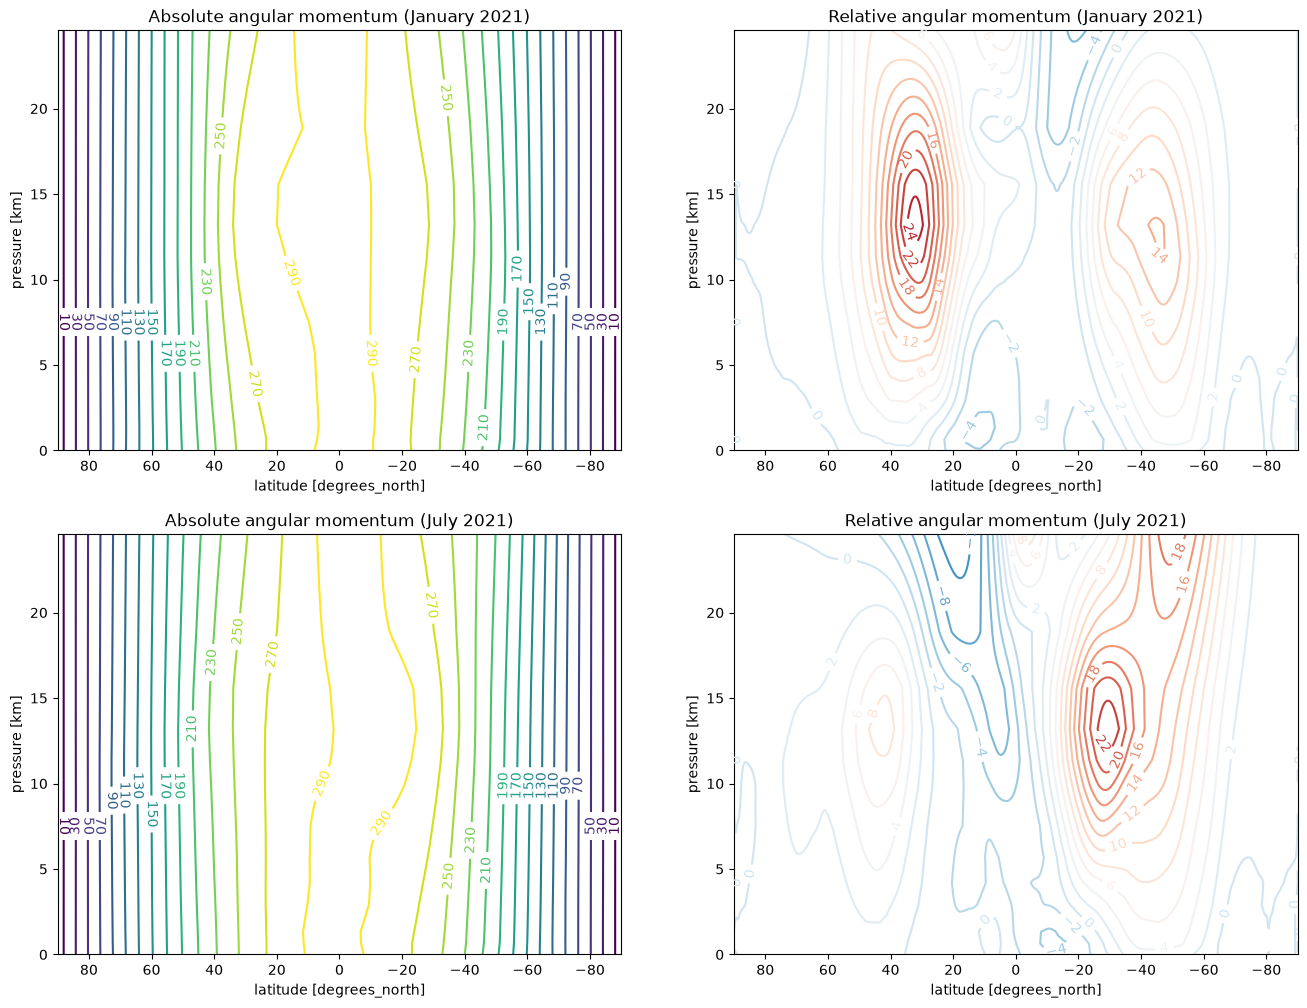

In [12]:
fig, axes = plt.subplots(2,2, figsize=(16,12))

for index, mon in enumerate(['January', 'July']):
    thisMrelative = Mrelative_computed[mon]
    thisMabs = thisMrelative + Mplanetary
    CS = thisMabs.plot.contour(y='geopotential_height', levels=np.arange(10,300,20), xincrease=False, ax=axes[index,0])
    axes[index,0].clabel(CS)
    axes[index,0].set_title('Absolute angular momentum (' + mon + ' 2021)')
    CS = thisMrelative.plot.contour(y='geopotential_height', levels=np.arange(-20,32,2), xincrease=False, ax=axes[index,1])
    axes[index,1].clabel(CS)
    axes[index,1].set_title('Relative angular momentum (' + mon + ' 2021)')

Are these figures broadly consistent with Randall's versions? What differences do you notice?

:::{note} Data exploration
We can and should compute the whole-atmosphere mass-weighted totals for the two months. It would be great to confirm that the total angular momentum is greater in N.H. winter, consistent with the LOD variations.

Work in progress!
:::

## Conservation of angular momentum

### A motionless parcel moves poleward...

The total angular momentum of a parcel is conserved in the absence of torques:

$$\frac{DM}{dt} = 0$$

or in other words, the quantity

$$\Omega a^2 \cos^2\phi + u a \cos\phi $$

is conserved for a moving parcel.

The fact that we **live on a sphere** becomes an interesting part of this problem.

Consider what happens to a parcel that starts out *motionless* ($u = 0$) at the equator ($\phi = 0$). Its initial angular momentum is 

$$ M = M_\Omega = \Omega a^2 $$

Now suppose this parcel moves toward the pole. Its *planetary* angular momentum decreases (since $\cos\phi$ is a decreasing function). This reflects the fact that the moment arm of the parcel (distance to the axis of rotation) gets smaller as the parcel moves poleward.

So to conserve total $M$, the zonal wind must increase!

Specifically in this situation, setting $M = \Omega a^2$ and solving for $u$ gives

$$ u = \Omega a \frac{ \sin^2\phi }{\cos\phi} $$

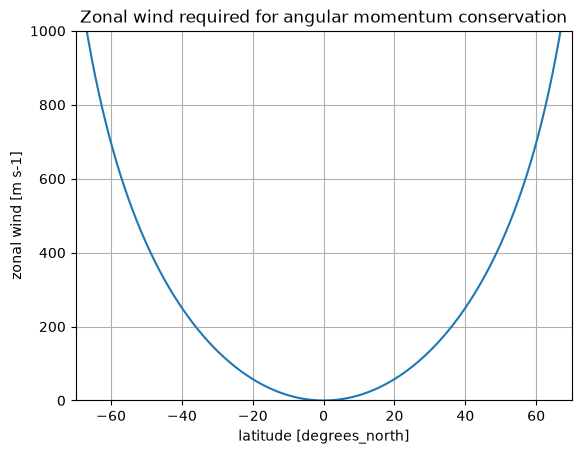

In [13]:
u_conserved = (Omega * a * np.sin(np.deg2rad(latitude))**2 / np.cos(np.deg2rad(latitude)))
u_conserved.attrs['long_name'] = 'zonal wind'
u_conserved.attrs['units'] = 'm s-1'
u_conserved.plot(xlim=(-70,70), ylim=(0,1000))
plt.grid()
plt.title('Zonal wind required for angular momentum conservation');

Key point here: notice that these required zonal wind values get very large (many hundreds of m/s)!

The effect of the shrinking moment arm as a parcel moves poleward seems to require **much larger zonal winds** that we actually observe. 

*Keep an eye on this as we explore the angular momentum budget of the observed atmosphere more fully.*

## Torques on the atmosphere

What physical processes govern changes in angular momentum in the atmosphere?

:::{note}
This is a deliberately sparse write-up of the equations, as we will develop the details together on the board in class.
:::

### Budget equations for angular momentum

Material changes on parcels are related to partial changes through

$$ \frac{D}{Dt} \equiv \frac{\partial}{\partial t} + \frac{u}{a \cos\phi} \frac{\partial}{\partial \lambda} + \frac{v}{a} \frac{\partial}{\partial \phi} + w \frac{\partial}{\partial z} $$

#### Changes in planetary angular momentum

So we can show that changes in planetary angular momentum for a moving parcel can be written as: 

$$ \frac{D M_\Omega}{Dt} = -a \cos\phi f v $$

This is known as the **Coriolis torque**.

#### Changes in relative angular momentum 

For the relative component we can write

$$ \frac{D M_r}{Dt} = a\cos\phi \frac{Du}{Dt} - uv \sin\phi $$

And we substitute in the zonal momentum equation (in "traditional" form)

$$ \frac{Du}{Dt} = fv + \frac{uv}{a} \tan\phi - \frac{1}{a \cos\phi} \frac{1}{\rho} \frac{\partial p}{\partial \lambda} + F_u $$

to get the simplified form

$$ \frac{D M_r}{Dt} = \underbrace{a\cos\phi f v}_{\text{Coriolis torque}} -\underbrace{\frac{1}{\rho}\frac{\partial p}{\partial \lambda}}_{\text{Zonal PGF torque}} + \underbrace{a\cos\phi F_u}_{\text{Frictonal torque}} $$

#### Total budget

The Coriolis torque is equal and opposite in the two budgets -- it represents the *exchange* between planetary and relative angular momentum, and drops out of the total budget:

$$ \frac{D M}{Dt} = -\frac{1}{\rho}\frac{\partial p}{\partial \lambda}  + a \cos\phi F_u$$

or, if we prefer to work in pressure coordinates,

$$ \frac{D M}{Dt} = -\frac{\partial \Phi}{\partial \lambda}  + a \cos\phi F_u$$

with geopotential $\Phi$.

### Mountain torques and frictional torques

A useful perspective here is the **zonal average**: let's see what we can learn about how different processes affect the zonal mean angular momemtum.

Working in pressure coordinate and writing the equation in flux form, we take the zonal average to get:

$$ \frac{\partial [M]}{\partial t} = -\frac{1}{a \cos\phi} \frac{\partial}{\partial \phi} \left( \cos\phi [vM] \right) - \frac{\partial}{\partial p} \left( [\omega M] \right) - \left[\frac{\partial \Phi}{\partial \lambda} \right] + a \cos\phi [F_u]$$

The third term on the RHS is called the **mountain torque** term:

$$ [T_M] \equiv - \left[\frac{\partial \Phi}{\partial \lambda} \right] = -\frac{1}{2\pi} \int_0^{2\pi} \frac{\partial \Phi}{\partial \lambda} d\lambda $$

Over most of the free atmosphere, this term must be zero since the geopotential $\Phi$ is continuous in longitude.

However, consider what happens when there are discontinuities in $\Phi$ at fixed latitude and pressure (or equivalently, discontinuities in pressure at fixed height):

:::{note}
Sketch of mountain torque here
:::

We have

\begin{align}
[T_M] &= -\frac{1}{2\pi} \left( \int_0^{\lambda_1} \frac{\partial \Phi}{\partial \lambda} d\lambda + \int_{\lambda_2}^{2\pi} \frac{\partial \Phi}{\partial \lambda} d\lambda \right)\\
&= -\frac{1}{2\pi} \left( \Phi(\lambda_1) - \Phi(0) + \Phi(2\pi) - \Phi(\lambda_2) \right)\\
&= -\frac{1}{2\pi} \left( \Phi_W - \Phi_E \right)
\end{align}

This is non-zero if the pressure is different at the same height on either side of the mountain range!

Suppose we have high pressure to the west, so that $[T_M] < 0$. Then in this case the atmosphere pushes the mountain to the east, but the Earth exerts an equal and opposite reaction against the atmosphere to the west. The angular momentum of the atmosphere locally decreases.

### Frictional torque

A reasonable starting assumption is that friction acts only at the lower boundary, and is a drag on the surface zonal wind:

$$ F_u \approx -\alpha u_s $$
with $u_s$ denoting the zonal wind at the surface.

Then our zonal-mean frictional torque would be

$$ [T_F] \equiv [a \cos\phi F_u] \approx -a \cos\phi \alpha [u] $$

- $[T_F] > 0$ when $[u] < 0$: surface *easterlies* add angular momentum
- $[T_F] < 0$ when $[u] > 0$: surface *westerlies* remove angular momentum

:::{note}
Sketch of climatological surface easterlies and westerlies
:::

The tropics act as a principle source of angular momentum and midlatitudes as the principle sink.

**Areas of surface westerlies and easterlies must balance** in the time mean such that angular momentum stays approximately constant

:::{note} Data exploration
We could plot surface winds from ERA5 and test how well they balanced in the global and time mean
:::

### Observed torques

:::{figure} ../images/Huang_torque.pdf
:alt: Zonally integrated torques
:width: 800px

Observed zonally integrated torques on the atmosphere. Units are Hadleys per 3.8º latitude (1 Hadley = 10$^{18}$ kg m$^2$ s$^{-2}$. Source: {cite:t}`Huang:1999a`
:::

Some key points here:

- Frictional torques generally dominate
- Mountain torques are important in the N.H. midlatitudes
- Winter Hadley cell is responsible for the largest angular momentum source
- S.H. shows less seasonal variance (widening of frictional torque from DJF -> JJA)

## Fluxes of angular momentum

The above figures of torques show that there is a **net supply of angular momentum** in the tropics and **net sink of angular momentum*** in the midlatitudes.

How does the angular momentum get redistributed with latitude?

### Zonal and time averaged angular momentum budget

Let's go back to our  angular momentum budget in flux form and take the time mean:

$$ \frac{\partial \overline{[M]}}{\partial t} = -\frac{1}{a \cos\phi} \frac{\partial}{\partial \phi} \left( \cos\phi [\overline{vM}] \right) - \frac{\partial}{\partial p} \left( [\overline{\omega M}] \right) + [\overline{T_M}] + [\overline{T_F}]$$

If there an approximate balance, then the LHS of the equation goes to zero, and we must find that atmospheric transport of angular momentum supply what's needed to balance the torques.

We now decompose the meridional flux $[\overline{vM}]$ into mean and eddy components

\begin{align*}
[\overline{vM}] &= [\overline{v}] \Omega a^2 \cos^2\phi + [\overline{uv}] a \cos\phi \\
&= [\overline{v}] \Omega a^2 \cos^2\phi + [\overline{u}][\overline{v}]a \cos\phi + [\overline{u}^* \overline{v}^*] a \cos\phi + [\overline{u^\prime v^\prime}]a \cos\phi 
\end{align*}

This equation says that the zonal, time mean meridional flux of angular momentum in comprised of

1. meridional flux of planetary angular momentum
2. meridonal flux of relative angular momentum by
    - mean meridional circulations
    - stationary eddies
    - transient eddies

How does this work?

The MMC transports angular momentum northward when $[\overline{u}]$ and $[\overline{v}]$ are positively correlated, i.e. southerlies associated with westerlies, and northerlies associated with easterlies.

Similarly for the eddy fluxes! Northward angular momentum transport results from *positive correlations between $u$ and $v$*.

:::{note}
Sketch of eddies with positive tilt from SW to NE
:::

### No net poleward transport of planetary angular momentum

We will focus mostly on the flux of relative angular momentum here. Why?

The total planetary flux, integrated with respect to mass over the depth of the atmosphere is

$$ \frac{1}{g} \int_0^{p_s} [\overline{v}] \Omega a^2 \cos^2\phi dp = \frac{\Omega a^2 \cos^2\phi}{g} \int_0^{p_s} [\overline{v}] dp = 0 $$

[Do you understand the physical argument here?]

As a consequence, it must be the fluxes of *relative* angular momentum that are responsible for the net meridional transport required to balance the torques.

### A classic view of the vertical structure of momentum fluxes

:::{figure} ../images/PO_fig11.7.pdf
:alt: Momentum flux cross-sections
:width: 800px

Zonal-mean cross section of the northward flux of momentum by all motions (a), transient eddies (b), stationary eddies (c), and mean meridional circulations (d) in m$^2$ s$^{-2}$ for annual-mean conditions. Source: {cite:t}`physicsofclimate`
:::

### Let's try to recreate this figure from the ERA5 data

:::{caution}
The code in this section has not been optimized for performance. It may take a long time to run, but hopefully the connection between the code and the theoretical quantities we are trying to compute is clear.
:::

We need to compute $[\overline{uv}]$ and its decomposition, so we'll need to load data for $v$.

In [14]:
v = pressure_spatial.v.sel(valid_time='2021')
v_zon = v.mean(dim='longitude')

In [15]:
uv = u * v
uv

<xarray.DataArray (valid_time: 8760, pressure_level: 13, latitude: 721,
                   longitude: 1440)> Size: 473GB
dask.array<mul, shape=(8760, 13, 721, 1440), dtype=float32, chunksize=(1, 1, 721, 1440), chunktype=numpy.ndarray>
Coordinates:
  * valid_time      (valid_time) datetime64[ns] 70kB 2021-01-01 ... 2021-12-3...
  * pressure_level  (pressure_level) float64 104B 1e+03 925.0 ... 100.0 50.0
  * latitude        (latitude) float64 6kB 90.0 89.75 89.5 ... -89.75 -90.0
  * longitude       (longitude) float64 12kB 0.0 0.25 0.5 ... 359.2 359.5 359.8
    lsm             (latitude, longitude) float32 4MB dask.array<chunksize=(721, 1440), meta=np.ndarray>
    sdor            (latitude, longitude) float32 4MB dask.array<chunksize=(721, 1440), meta=np.ndarray>
    slor            (latitude, longitude) float32 4MB dask.array<chunksize=(721, 1440), meta=np.ndarray>
    z_sfc           (latitude, longitude) float32 4MB dask.array<chunksize=(721, 1440), meta=np.ndarray>
Attributes: (12/24)
    GRIB_dataType:                            an
    GRIB_numberOfPoints:                      1038240
    GRIB_typeOfLevel:                         isobaricInhPa
    GRIB_stepUnits:                           1
    GRIB_stepType:                            instant
    GRIB_gridType:                            regular_ll
    ...                                       ...
    GRIB_longitudeOfFirstGridPointInDegrees:  0.0
    GRIB_longitudeOfLastGridPointInDegrees:   359.75
    GRIB_missingValue:                        3.4028234663852886e+38
    GRIB_totalNumber:                         0
    GRIB_units:                               m s**-1
    units:                                    m s**-1

In [16]:
uv_zon = uv.mean(dim='longitude')
uv_zon

<xarray.DataArray (valid_time: 8760, pressure_level: 13, latitude: 721)> Size: 328MB
dask.array<mean_agg-aggregate, shape=(8760, 13, 721), dtype=float32, chunksize=(1, 1, 721), chunktype=numpy.ndarray>
Coordinates:
  * valid_time      (valid_time) datetime64[ns] 70kB 2021-01-01 ... 2021-12-3...
  * pressure_level  (pressure_level) float64 104B 1e+03 925.0 ... 100.0 50.0
  * latitude        (latitude) float64 6kB 90.0 89.75 89.5 ... -89.75 -90.0
Attributes: (12/24)
    GRIB_dataType:                            an
    GRIB_numberOfPoints:                      1038240
    GRIB_typeOfLevel:                         isobaricInhPa
    GRIB_stepUnits:                           1
    GRIB_stepType:                            instant
    GRIB_gridType:                            regular_ll
    ...                                       ...
    GRIB_longitudeOfFirstGridPointInDegrees:  0.0
    GRIB_longitudeOfLastGridPointInDegrees:   359.75
    GRIB_missingValue:                        3.4028234663852886e+38
    GRIB_totalNumber:                         0
    GRIB_units:                               m s**-1
    units:                                    m s**-1

In [17]:
uv_zon_mon = uv_zon.groupby(uv_zon.valid_time.dt.month).mean(dim='valid_time')
uv_zon_mon

<xarray.DataArray (month: 12, pressure_level: 13, latitude: 721)> Size: 450kB
dask.array<transpose, shape=(12, 13, 721), dtype=float32, chunksize=(1, 1, 721), chunktype=numpy.ndarray>
Coordinates:
  * month           (month) int64 96B 1 2 3 4 5 6 7 8 9 10 11 12
  * pressure_level  (pressure_level) float64 104B 1e+03 925.0 ... 100.0 50.0
  * latitude        (latitude) float64 6kB 90.0 89.75 89.5 ... -89.75 -90.0
Attributes: (12/24)
    GRIB_dataType:                            an
    GRIB_numberOfPoints:                      1038240
    GRIB_typeOfLevel:                         isobaricInhPa
    GRIB_stepUnits:                           1
    GRIB_stepType:                            instant
    GRIB_gridType:                            regular_ll
    ...                                       ...
    GRIB_longitudeOfFirstGridPointInDegrees:  0.0
    GRIB_longitudeOfLastGridPointInDegrees:   359.75
    GRIB_missingValue:                        3.4028234663852886e+38
    GRIB_totalNumber:                         0
    GRIB_units:                               m s**-1
    units:                                    m s**-1

Let's define terms in the decomposition

$$ [\overline{uv}] = [\overline{u}][\overline{v}] + [\overline{u}^* \overline{v}^*]  + [\overline{u^\prime v^\prime}] $$

We'll work on $[\overline{u}][\overline{v}]$ first:

In [18]:
u_zon = u.mean(dim='longitude')
u_zon_mon = u_zon.groupby(u_zon.valid_time.dt.month).mean(dim='valid_time')
v_zon = v.mean(dim='longitude')
v_zon_mon = v_zon.groupby(v_zon.valid_time.dt.month).mean(dim='valid_time')
flux_mmc = u_zon_mon * v_zon_mon
flux_mmc

<xarray.DataArray (month: 12, pressure_level: 13, latitude: 721)> Size: 450kB
dask.array<mul, shape=(12, 13, 721), dtype=float32, chunksize=(1, 1, 721), chunktype=numpy.ndarray>
Coordinates:
  * month           (month) int64 96B 1 2 3 4 5 6 7 8 9 10 11 12
  * pressure_level  (pressure_level) float64 104B 1e+03 925.0 ... 100.0 50.0
  * latitude        (latitude) float64 6kB 90.0 89.75 89.5 ... -89.75 -90.0
Attributes: (12/24)
    GRIB_dataType:                            an
    GRIB_numberOfPoints:                      1038240
    GRIB_typeOfLevel:                         isobaricInhPa
    GRIB_stepUnits:                           1
    GRIB_stepType:                            instant
    GRIB_gridType:                            regular_ll
    ...                                       ...
    GRIB_longitudeOfFirstGridPointInDegrees:  0.0
    GRIB_longitudeOfLastGridPointInDegrees:   359.75
    GRIB_missingValue:                        3.4028234663852886e+38
    GRIB_totalNumber:                         0
    GRIB_units:                               m s**-1
    units:                                    m s**-1

And now work on $[\overline{u}^* \overline{v}^*]$:

In [19]:
ustar = (u - u_zon)
vstar = (v - v_zon)
vstar

<xarray.DataArray 'v' (valid_time: 8760, pressure_level: 13, latitude: 721,
                       longitude: 1440)> Size: 473GB
dask.array<sub, shape=(8760, 13, 721, 1440), dtype=float32, chunksize=(1, 1, 721, 1440), chunktype=numpy.ndarray>
Coordinates:
  * valid_time      (valid_time) datetime64[ns] 70kB 2021-01-01 ... 2021-12-3...
  * pressure_level  (pressure_level) float64 104B 1e+03 925.0 ... 100.0 50.0
  * latitude        (latitude) float64 6kB 90.0 89.75 89.5 ... -89.75 -90.0
  * longitude       (longitude) float64 12kB 0.0 0.25 0.5 ... 359.2 359.5 359.8
    lsm             (latitude, longitude) float32 4MB dask.array<chunksize=(721, 1440), meta=np.ndarray>
    sdor            (latitude, longitude) float32 4MB dask.array<chunksize=(721, 1440), meta=np.ndarray>
    slor            (latitude, longitude) float32 4MB dask.array<chunksize=(721, 1440), meta=np.ndarray>
    z_sfc           (latitude, longitude) float32 4MB dask.array<chunksize=(721, 1440), meta=np.ndarray>
Attributes: (12/31)
    GRIB_paramId:                             132
    GRIB_dataType:                            an
    GRIB_numberOfPoints:                      1038240
    GRIB_typeOfLevel:                         isobaricInhPa
    GRIB_stepUnits:                           1
    GRIB_stepType:                            instant
    ...                                       ...
    GRIB_shortName:                           v
    GRIB_totalNumber:                         0
    GRIB_units:                               m s**-1
    long_name:                                V component of wind
    units:                                    m s**-1
    standard_name:                            northward_wind

In [20]:
ustar_mon = ustar.groupby(ustar.valid_time.dt.month).mean(dim='valid_time')
vstar_mon = vstar.groupby(vstar.valid_time.dt.month).mean(dim='valid_time')
flux_stationary = (ustar_mon * vstar_mon).mean(dim='longitude')
flux_stationary

<xarray.DataArray (month: 12, pressure_level: 13, latitude: 721)> Size: 450kB
dask.array<mean_agg-aggregate, shape=(12, 13, 721), dtype=float32, chunksize=(1, 1, 721), chunktype=numpy.ndarray>
Coordinates:
  * month           (month) int64 96B 1 2 3 4 5 6 7 8 9 10 11 12
  * pressure_level  (pressure_level) float64 104B 1e+03 925.0 ... 100.0 50.0
  * latitude        (latitude) float64 6kB 90.0 89.75 89.5 ... -89.75 -90.0
Attributes: (12/24)
    GRIB_dataType:                            an
    GRIB_numberOfPoints:                      1038240
    GRIB_typeOfLevel:                         isobaricInhPa
    GRIB_stepUnits:                           1
    GRIB_stepType:                            instant
    GRIB_gridType:                            regular_ll
    ...                                       ...
    GRIB_longitudeOfFirstGridPointInDegrees:  0.0
    GRIB_longitudeOfLastGridPointInDegrees:   359.75
    GRIB_missingValue:                        3.4028234663852886e+38
    GRIB_totalNumber:                         0
    GRIB_units:                               m s**-1
    units:                                    m s**-1

And finally we'll work on $[\overline{u^\prime v^\prime}]$.

Here we need to be careful to be consistent in the time interval we're using to define the average $(\overline{~})$ and the deviation away from that average $(~^\prime)$.

In [21]:
ubar_mon = u.groupby(u.valid_time.dt.month).mean(dim='valid_time')
vbar_mon = v.groupby(v.valid_time.dt.month).mean(dim='valid_time')

uprime_mon = u.groupby(u.valid_time.dt.month) - ubar_mon
vprime_mon = v.groupby(v.valid_time.dt.month) - vbar_mon

flux_transient = (uprime_mon * vprime_mon).groupby(u.valid_time.dt.month).mean(dim=('valid_time','longitude'))
flux_transient

<xarray.DataArray (month: 12, pressure_level: 13, latitude: 721)> Size: 450kB
dask.array<transpose, shape=(12, 13, 721), dtype=float32, chunksize=(1, 1, 721), chunktype=numpy.ndarray>
Coordinates:
  * month           (month) int64 96B 1 2 3 4 5 6 7 8 9 10 11 12
  * pressure_level  (pressure_level) float64 104B 1e+03 925.0 ... 100.0 50.0
  * latitude        (latitude) float64 6kB 90.0 89.75 89.5 ... -89.75 -90.0
Attributes: (12/24)
    GRIB_dataType:                            an
    GRIB_numberOfPoints:                      1038240
    GRIB_typeOfLevel:                         isobaricInhPa
    GRIB_stepUnits:                           1
    GRIB_stepType:                            instant
    GRIB_gridType:                            regular_ll
    ...                                       ...
    GRIB_longitudeOfFirstGridPointInDegrees:  0.0
    GRIB_longitudeOfLastGridPointInDegrees:   359.75
    GRIB_missingValue:                        3.4028234663852886e+38
    GRIB_totalNumber:                         0
    GRIB_units:                               m s**-1
    units:                                    m s**-1

#### Time to actually compute some results!

As before, we'll carry out the calculation for the months of January and July.

:::{caution}
These will take a long time to run! Even on the HPC cluster, the total run time may be 15 minutes or more.

The dask warnings indicate complicated parallelization tasks and suggest room for improvement in efficiency. But this code will get the job done if we are patient.
:::

In [22]:
%%time
flux_total_computed = {'January': uv_zon_mon.sel(month=1).compute(),
                      'July': uv_zon_mon.sel(month=7).compute()
                     }

/network/rit/lab/snowclus/pixi/aug26/.pixi/envs/default/lib/python3.14/site-packages/distributed/client.py:3429: UserWarning: Sending large graph of size 30.32 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(
/network/rit/lab/snowclus/pixi/aug26/.pixi/envs/default/lib/python3.14/site-packages/distributed/client.py:3429: UserWarning: Sending large graph of size 30.32 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


CPU times: user 1min 56s, sys: 7.7 s, total: 2min 3s
Wall time: 2min 27s


In [23]:
%%time
flux_mmc_computed = {'January': flux_mmc.sel(month=1).compute(),
                     'July': flux_mmc.sel(month=7).compute()
                    }

/network/rit/lab/snowclus/pixi/aug26/.pixi/envs/default/lib/python3.14/site-packages/distributed/client.py:3429: UserWarning: Sending large graph of size 40.90 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(
/network/rit/lab/snowclus/pixi/aug26/.pixi/envs/default/lib/python3.14/site-packages/distributed/client.py:3429: UserWarning: Sending large graph of size 40.90 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


CPU times: user 2min 4s, sys: 7.53 s, total: 2min 11s
Wall time: 2min 39s


In [24]:
%%time
flux_stationary_computed = {'January': flux_stationary.sel(month=1).compute(),
                            'July': flux_stationary.sel(month=7).compute()
                           }

/network/rit/lab/snowclus/pixi/aug26/.pixi/envs/default/lib/python3.14/site-packages/distributed/client.py:3429: UserWarning: Sending large graph of size 61.17 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(
/network/rit/lab/snowclus/pixi/aug26/.pixi/envs/default/lib/python3.14/site-packages/distributed/client.py:3429: UserWarning: Sending large graph of size 61.17 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


CPU times: user 3min 11s, sys: 11.5 s, total: 3min 23s
Wall time: 4min 49s


In [25]:
%%time
flux_transient_computed = {'January': flux_transient.sel(month=1).compute(),
                           'July': flux_transient.sel(month=7).compute()
                          }

/network/rit/lab/snowclus/pixi/aug26/.pixi/envs/default/lib/python3.14/site-packages/distributed/client.py:3429: UserWarning: Sending large graph of size 63.57 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(
/network/rit/lab/snowclus/pixi/aug26/.pixi/envs/default/lib/python3.14/site-packages/distributed/client.py:3429: UserWarning: Sending large graph of size 63.57 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


CPU times: user 3min 32s, sys: 12.9 s, total: 3min 45s
Wall time: 6min 4s


### Now it's time to make some plots

Let's make a plot like the one above from Peixoto and Oort showing the vertical cross-section of the fluxes and their decomposition

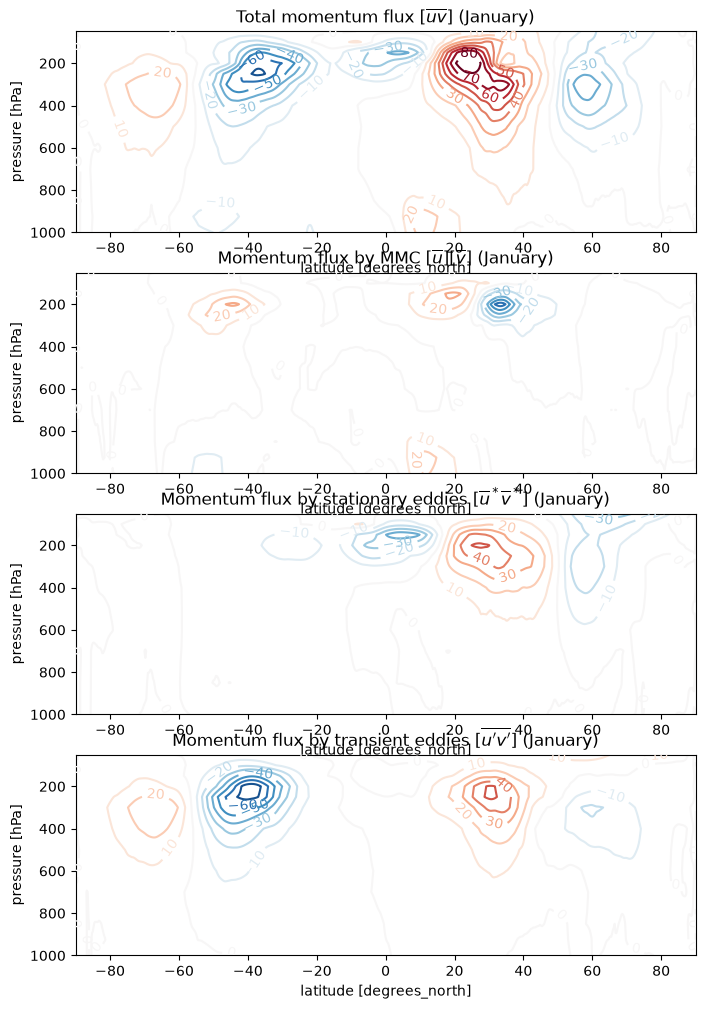

In [26]:
month = 'January'
levs = np.arange(-80,85,10)

fig, axes = plt.subplots(4,1, figsize=(8,12))

for num, flux in enumerate([flux_total_computed,
                             flux_mmc_computed,
                             flux_stationary_computed,
                             flux_transient_computed]
                           ):
    CS = flux[month].plot.contour(ax=axes[num],
                                  yincrease=False, 
                                  levels=levs,
                                 )
    axes[num].clabel(CS)

axes[0].set_title(r'Total momentum flux $[\overline{uv}]$ (January)')
axes[1].set_title(r'Momentum flux by MMC $[\overline{u}][\overline{v}]$ (January)')
axes[2].set_title(r'Momentum flux by stationary eddies $[\overline{u}^* \overline{v}^*]$ (January)')
axes[3].set_title(r'Momentum flux by transient eddies $[\overline{u^\prime v^\prime}]$ (January)');

A few things to note here:
- The transient eddy term is large at upper levels
- The stationary eddy term is also large in the Northerm Hemisphere winter (stationary waves)
- MMC term is smaller but carries the signature of the overturning circulation

#### What does this look like in the opposite season?

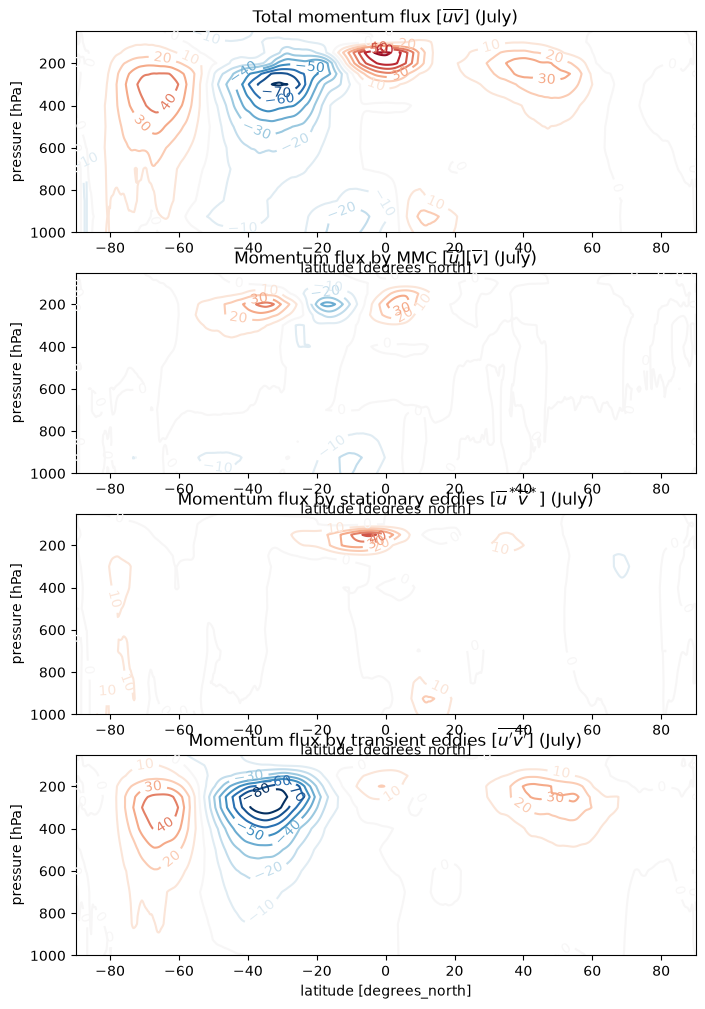

In [27]:
month = 'July'
levs = np.arange(-80,85,10)

fig, axes = plt.subplots(4,1, figsize=(8,12))

for num, flux in enumerate([flux_total_computed,
                             flux_mmc_computed,
                             flux_stationary_computed,
                             flux_transient_computed]
                           ):
    CS = flux[month].plot.contour(ax=axes[num],
                                  yincrease=False, 
                                  levels=levs,
                                 )
    axes[num].clabel(CS)

axes[0].set_title(r'Total momentum flux $[\overline{uv}]$ (July)')
axes[1].set_title(r'Momentum flux by MMC $[\overline{u}][\overline{v}]$ (July)')
axes[2].set_title(r'Momentum flux by stationary eddies $[\overline{u}^* \overline{v}^*]$ (July)')
axes[3].set_title(r'Momentum flux by transient eddies $[\overline{u^\prime v^\prime}]$ (July)');

The transient eddy term dominates the Southern Hemisphere winter. As usual, the stationary eddy term is small in this season (winter in the South, summer in the North)

### A vertically integrated view

:::{figure} ../images/PO_fig11.8.pdf
:alt: Northward transport of momentum
:width: 800px

Meridional profiles of the vertical- and zonal-mean northward transport of momentum by all motions (a), transient eddies (b), stationary eddies (c), and mean meridional circulations (d) in units of m$^2$ s$^{-2}$ for annual, DJF, and JJA mean conditions. Source: {cite:t}`physicsofclimate`
:::

- Seasonal cycle more apparent in N.H.
- Transient eddy component still dominates
- MMC component more important at solstices than suggested by the annual mean
- S.H. slightly greater peak flux of angular momentum compared to N.H. (compensation by the ocean?)

:::{note} Data exploration
We should be able to recreate a version of this vertically integrated figure from the ERA5 data.
:::

## Streamlines of angular momentum flux

In the long term mean, we suppose there's a steady state at each latitude

$$\frac{\partial [\overline{M}]}{\partial t} = 0 $$

so the steady-state budget looks like

$$0 = -\frac{1}{a\cos\phi} \frac{\partial}{\partial \phi} \left( [\overline{vM}] \cos\phi \right) - \frac{\partial}{\partial p} \left( [\overline{\omega M} ] \right) - \left[ \frac{\partial \overline{\Phi}}{\partial \lambda} \right] + a \cos\phi \left[ \overline{F_u} \right] $$

Now for notational convenience, let's wrap all our torques together like this:

$$ \frac{\partial [\overline{\tau}]}{\partial p} = \frac{1}{a \cos\phi} \left[ \frac{\partial \overline{\Phi}}{\partial \lambda} \right] - \left[ \overline{F_u} \right] $$

and subtract out the planetary angular momentum flux since it can't contribute to net poleward transport of absolute angular momentum.

The budget becomes

$$ 0 = -\frac{1}{a\cos\phi} \frac{\partial}{\partial \phi} \left( [\overline{vM_r}] \cos\phi \right) - \frac{\partial}{\partial p} \left( [\overline{\omega M_r} ] + a \cos\phi [\overline{\tau}] \right) $$

Let's now define an *angular momentum streamfunction* $\psi_M$ as follows:

\begin{align*}
2\pi a \cos\phi [\overline{vM_r}] &= -\frac{\partial \psi_M}{\partial p} \\
2\pi a^2 \cos\phi \left( [\overline{\omega M_r}] + a \cos\phi [\overline{\tau}] \right) = \frac{\partial \psi_M}{\partial \phi}
\end{align*}

(This defintion should satisfy non-divergence in the $p-\phi$ plane. Does it?)

The streamfunction $\psi_M$ is a function in the $(\phi, p)$ plane whose contours give the direction of the angular momentum transport.

### A plot of the streamlines

This gives a visual sense of the direction of angular momentum transport by various components of the flow:

:::{figure} ../images/PO_fig11.13.pdf
:alt: Northward transport of momentum
:width: 800px

Streamlines of the nondivergent component of the zonal-mean transport of relative angular momentum in the atmosphere. Source: {cite:t}`physicsofclimate`
:::

:::{note} Data exploration
Again, we should be able to recreate our own version of this plot from the ERA5 data!
:::

Some things to note here:
- We have a near-surface source of angular momentum in the tropics *(frictional torque associated with easterly trade winds)*
- There is upward tranpsort of angular momentum by the mean meridional circulation in the tropics / subtropics
- Horizontal (poleward) transport of angular momentum in upper tropopsphere associated with eddies
- Downward transport in the midlatitudes
- A sink in westerly angular momentum in midlatitudes *(frictional torque associated with surface westerlies)*

Seasonally, the main source of angular momentum is in the tropics / subtropics of the winter hemisphere where the easterly trades are strongest.

## Clean up our computational environment

When we are done with the number crunching, we should close the cluster and release those resources back to the next user.

In [28]:
cluster.close()